In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from tensorflow import keras
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

def save_plot(filename):
    plt.savefig(f'../figures/{filename}.png', dpi=300, bbox_inches='tight')

Loading Data, Scalers, and Best Model

In [2]:
X_train = np.load('../data/processed/X_train.npy')
y_train = np.load('../data/processed/y_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_test = np.load('../data/processed/y_test.npy')

scaler_X = joblib.load('../models/scaler_X.save')
scaler_y = joblib.load('../models/scaler_y.save')
ann_model = keras.models.load_model('../models/best_model_iloilo.keras', compile=False)

Training Linear Regression Baseline

In [3]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train.ravel())

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Generate Predictions

In [4]:
y_pred_scaled_ann = ann_model.predict(X_test)
y_pred_scaled_lr = lr_model.predict(X_test).reshape(-1, 1)

206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 853us/step


Inverse Transforming to real kWh before calculating metrics

In [6]:
y_test_real = scaler_y.inverse_transform(y_test)
y_pred_ann = scaler_y.inverse_transform(y_pred_scaled_ann)
y_pred_lr = scaler_y.inverse_transform(y_pred_scaled_lr)

X_test_cont = X_test[:, :6]
X_test_cat = X_test[:, 6:]

X_test_cont_real = scaler_X.inverse_transform(X_test_cont)

X_test_real = np.hstack((X_test_cont_real, X_test_cat))

Calculate Final Metrics

In [7]:
def print_metrics(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name}")
    print(f"RMSE: {rmse:.4f} kWh")
    print(f"MAE:  {mae:.4f} kWh")
    print(f"R²:   {r2:.4f}\n")
    
print_metrics("Linear Regression Baseline", y_test_real, y_pred_lr)
print_metrics("ANN Model", y_test_real, y_pred_ann)

Linear Regression Baseline
RMSE: 0.0646 kWh
MAE:  0.0383 kWh
R²:   0.9002

ANN Model
RMSE: 0.0519 kWh
MAE:  0.0291 kWh
R²:   0.9356



Visualizations

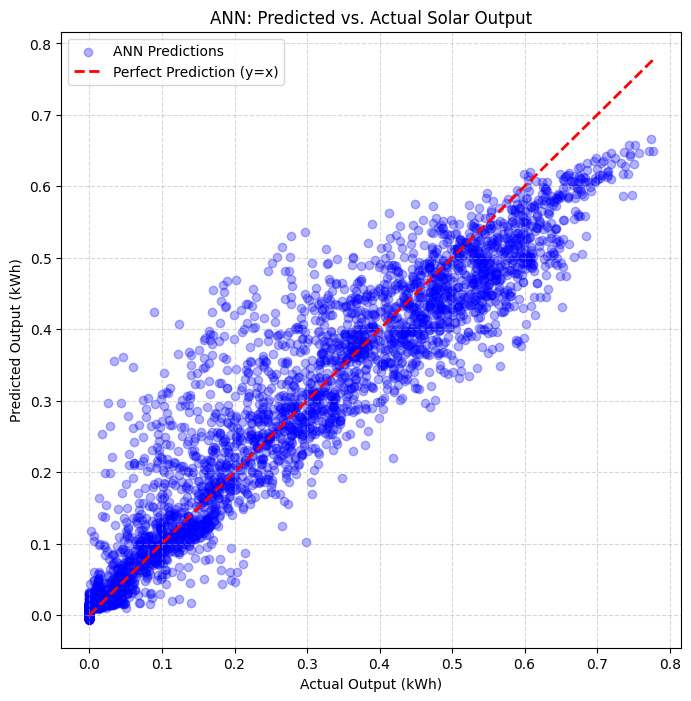

In [8]:
# Predicted vs Actual Scatter Plot
plt.figure(figsize=(8, 8))
plt.scatter(y_test_real, y_pred_ann, alpha=0.3, color='blue', label='ANN Predictions')

# Perfect prediction line
max_val = max(np.max(y_test_real), np.max(y_pred_ann))
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction (y=x)')
plt.title('ANN: Predicted vs. Actual Solar Output')
plt.xlabel('Actual Output (kWh)')
plt.ylabel('Predicted Output (kWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
save_plot('predicted_vs_actual_scatter')
plt.show()

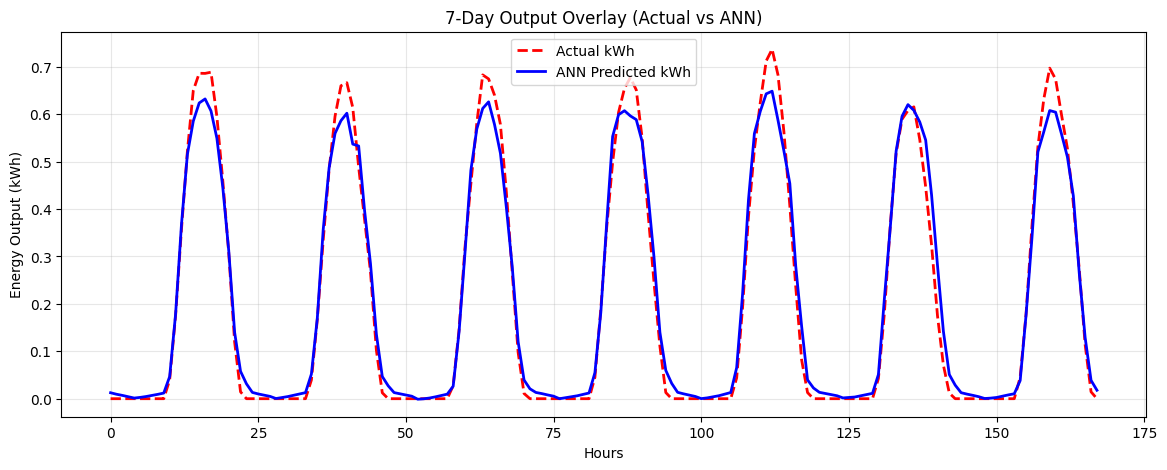

In [9]:
# 7-Day Time-Series Overlay
# 7 days * 24 hours = 168 hours of random 7-day window from the test set.
start_idx = 500 
end_idx = start_idx + 168

plt.figure(figsize=(14, 5))
plt.plot(y_test_real[start_idx:end_idx], label='Actual kWh', color='red', linestyle='--', linewidth=2)
plt.plot(y_pred_ann[start_idx:end_idx], label='ANN Predicted kWh', color='blue', linewidth=2)
plt.title('7-Day Output Overlay (Actual vs ANN)')
plt.xlabel('Hours')
plt.ylabel('Energy Output (kWh)')
plt.legend()
plt.grid(True, alpha=0.3)
save_plot('7_day_timeseries_overlay')
plt.show()

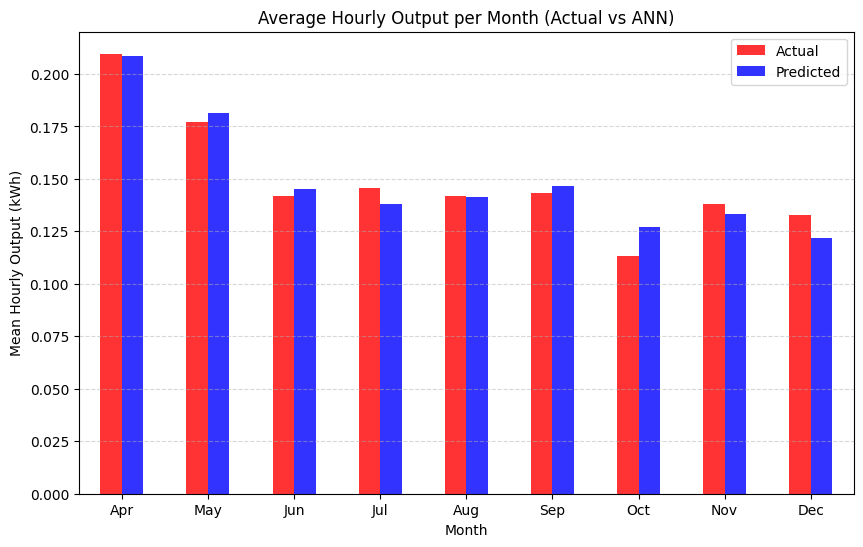

In [10]:
import calendar

# Monthly Average Output
months_test = X_test_real[:, 7]

df_eval = pd.DataFrame({
    'Month': months_test.astype(int), 
    'Actual': y_test_real.flatten(),
    'Predicted': y_pred_ann.flatten()
})

df_eval['Month'] = df_eval['Month'].apply(lambda x: calendar.month_abbr[x])

month_order = list(calendar.month_abbr)[1:] 
df_eval['Month'] = pd.Categorical(df_eval['Month'], categories=month_order, ordered=True)

monthly_avg = df_eval.groupby('Month').mean()

monthly_avg.plot(kind='bar', figsize=(10, 6), color=['red', 'blue'], alpha=0.8)
plt.title('Average Hourly Output per Month (Actual vs ANN)')
plt.xlabel('Month')
plt.ylabel('Mean Hourly Output (kWh)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
save_plot('monthly_average_barchart')
plt.show()

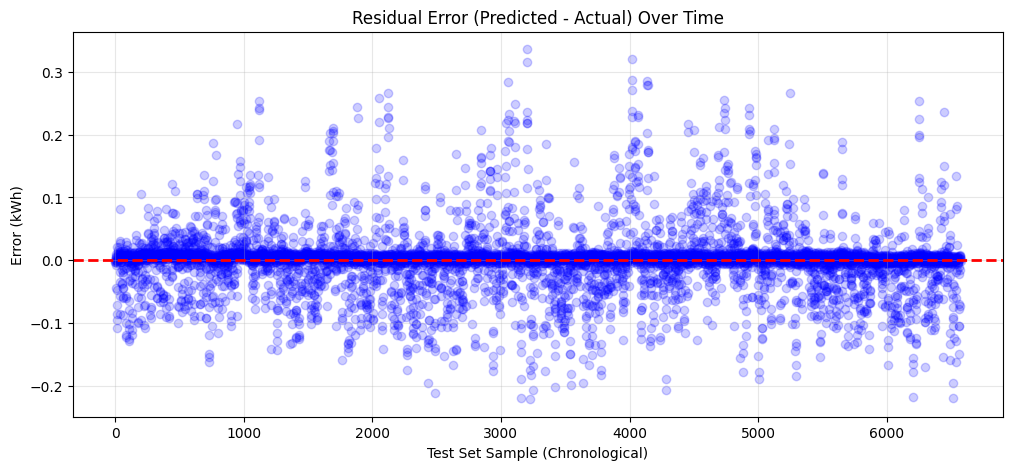

In [11]:
# Residual Error Plot
residuals = y_pred_ann - y_test_real

plt.figure(figsize=(12, 5))
plt.scatter(range(len(residuals)), residuals, alpha=0.2, color='blue')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Error (Predicted - Actual) Over Time')
plt.xlabel('Test Set Sample (Chronological)')
plt.ylabel('Error (kWh)')
plt.grid(True, alpha=0.3)
save_plot('residual_error_plot')
plt.show()